## Demo for modelling single-channel PSF from SMLM data

#### Setup environment

In [1]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf

try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_base')
```

In [2]:
L = psflearninglib()
L.param = io.param.combine(basefile='config_base',psftype='insitu',channeltype='1ch',sysfile='smart_tirf')

#### Edit user defined parameters

In [3]:
L.param.datapath = r'C:\Users\Sheng\Documents\MATLAB\DNA-Paint/ruler/'
L.param.keyword = '20R-ruler-0.05exp-FocusLock-noPol--2025-06-17_12-47-59' # keyword of the file name or the full file name without extension
L.param.savename =  L.param.datapath+'result_1ch/' + L.param.keyword
L.param.gain = 0.25
L.param.ccd_offset = 100
L.param.roi.peak_height = 0.05
L.param.varname = 'Main/data'
L.param.option.insitu.stage_pos = 0.6 # micron, stage position relative to infocus at the coverslip
L.param.option.insitu.zernike_index=[5]
L.param.option.insitu.zernike_coeff=[0.5]
L.param.option.model.const_pupilmag = True
L.param.option.insitu.var_stagepos = False
L.param.option.insitu.stage_tilt = [0,0]
L.param.option.insitu.repeat = 2
L.param.option.insitu.z_range = 1.0
L.param.insitu.frame_range = [1000,1500]
L.param.batch_size = 1000 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.plotall = True

#### Start learning

In [4]:
images = L.load_data()

C:\Users\Sheng\Documents\MATLAB\DNA-Paint/ruler\20R-ruler-0.05exp-FocusLock-noPol--2025-06-17_12-47-59.h5
(500, 1000, 256)


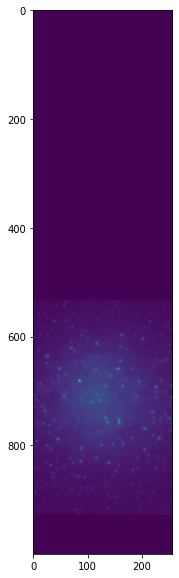

In [5]:
plt.figure(figsize=(10,10))
plt.imshow(images[0])


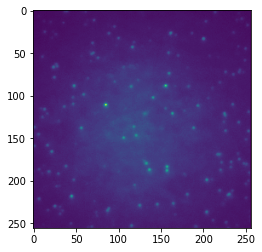

In [ ]:
imsz = 256
startx = 0
starty = 570
plt.imshow(images[0][starty:starty+imsz,startx:startx+imsz])
print('Image size:', images[0][starty:starty+imsz,startx:startx+imsz].shape)

In [ ]:
images = images[:,starty:starty+imsz,startx:startx+imsz]

rois shape channel : (13241, 15, 15)


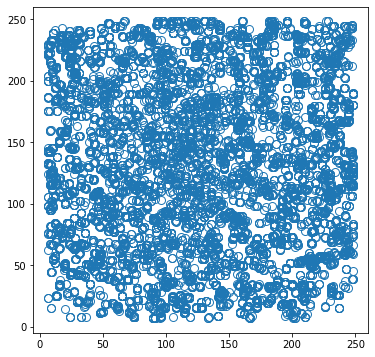

In [13]:
L.getpsfclass()
L.param.roi.roi_size = [15,15]
L.param.roi.peak_height = 0.1
dataobj = L.prep_data(images)

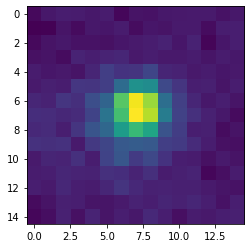

In [15]:
plt.imshow(dataobj.rois[400])

4/6: calculating spline coefficients: 1/1 [00:00s]  2.65it/s total time: 0.37s
5/6: localization: 2/2 [00:00s]  5.94it/s total time: 0.70s
3/6: learning: 297/? [01:08s]  4.31it/s, current loss: 1.57598, total time: 68.84s   


outlier percentage: 0.2328843995510662
rois shape channel : (1367, 15, 15)


3/6: learning: 166/250 [00:35s]  4.64it/s, current loss: 1.21479, total time: 104.60s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.61it/s total time: 0.38s
5/6: localization: 2/2 [00:00s] 63.45it/s total time: 0.41s
6/6: saving results: [00:00s] total time: 0.83s


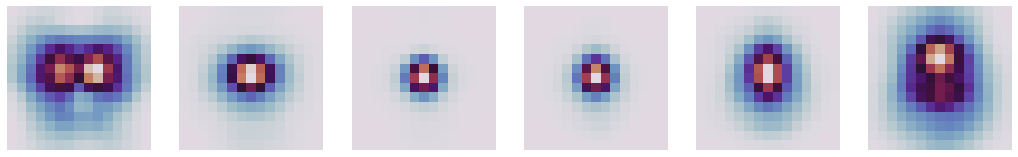

4/6: calculating spline coefficients: 1/1 [00:00s]  2.56it/s total time: 0.38s
5/6: localization: 2/2 [00:00s] 25.11it/s total time: 0.46s
3/6: learning: 176/250 [00:39s]  4.47it/s, current loss: 1.39059, total time: 39.33s


outlier percentage: 0.2315051020408163
rois shape channel : (1205, 15, 15)


3/6: learning: 235/250 [00:49s]  4.78it/s, current loss: 1.07571, total time: 88.50s
4/6: calculating spline coefficients: 1/1 [00:00s]  2.46it/s total time: 0.40s
5/6: localization: 2/2 [00:00s] 49.42it/s total time: 0.44s
6/6: saving results: [00:00s] total time: 0.86s


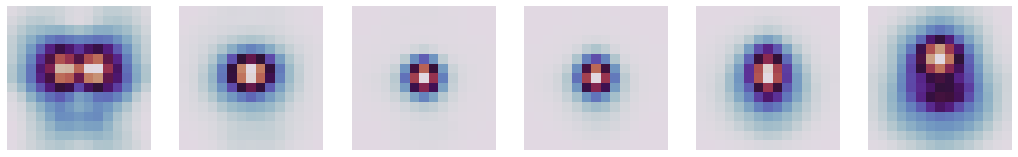

In [16]:
resfile = L.iterlearn_psf(dataobj,time=0)

#### Show results

In [17]:
f,p = io.h5.load(resfile) # load result file

In [18]:
f.res.sigma

array([0.6866096, 0.673805 ], dtype=float32)

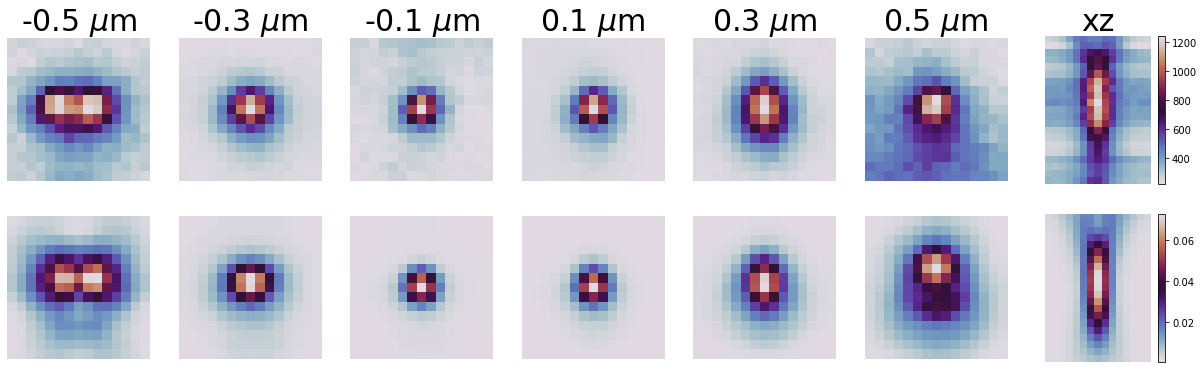

In [19]:
showpsfvsdata_insitu(f,p)

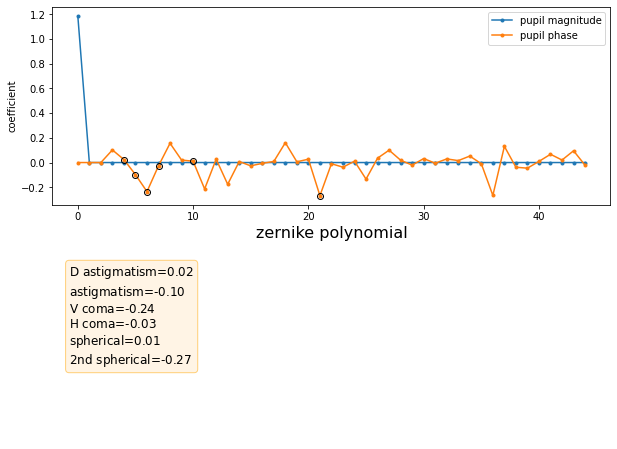

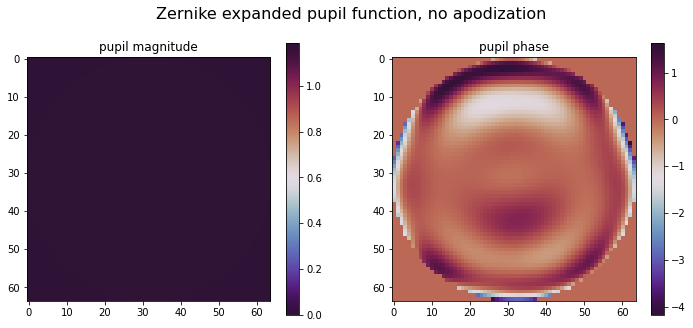

In [20]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

##### Optional plots

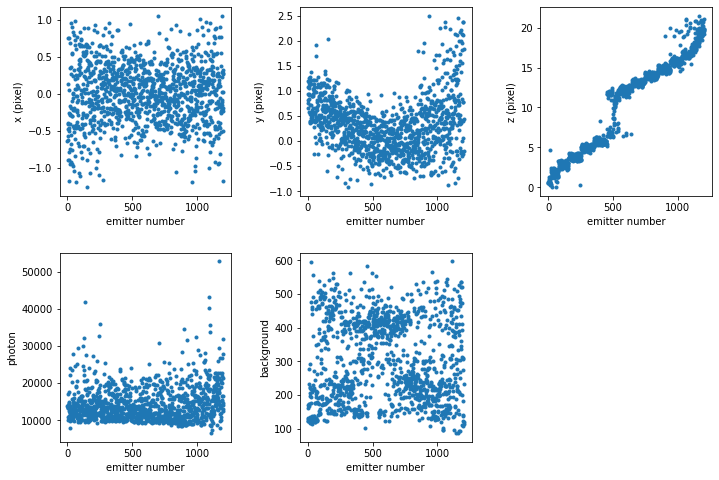

In [21]:
showlearnedparam_insitu(f,p)

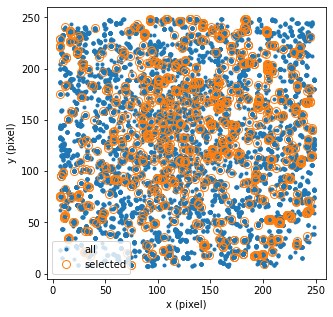

In [22]:
showcoord(f,p)

#### Ouput parameters

In [11]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['I_model', 'apodization', 'bg', 'cor', 'cor_all', 'intensity', 'offset', 'pos', 'pupil', 'sigma', 'stagepos', 'stagetilt', 'zernike_coeff', 'zernike_polynomial', 'zoffset']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
